# Model free predictions

Previously, known MDP.

Now no one tells us the environment. 

Estimate the value function of an unknown MDP (unknown state transitions and rewards)

1. Monte-Carlo Learning (MC): run all the way trajectories & estimate value by sampling returns
2. Temporal-Diﬀerence Learning (TD): more efficient in practice. look one step ahead and then estimate the returns
3. TD(λ): unify both MC and TD

Then (next notebok), model-free control: optimize the value function of an unknown MDP

## Monte-carlo RL

- MC methods learn directly from **episodes** of experience (**ONLY for episodic MDP**)
- MC is model-free: no knowledge of MDP transitions / rewards
- MC learns from complete episodes: no bootstrapping
- MC uses the simplest possible idea: value = mean return
- Caveat: can only apply MC to episodic MDPs
- All episodes must terminate

### Policy evaluation

Goal: learn $v_π$ from episodes of experience under policy π

$$S_1,A_1,R_2,...,S_k ∼π$$

Recall that the return is the total discounted reward:

$$G_t = R_{t+1} + γR_{t+2} +...+ γ^{T−1}R_T$$

Recall that the value function is the expected return:

$$v_π (s) = E_π [G_t |S_t = s]$$

Monte-Carlo policy evaluation uses empirical mean return
instead of expected return

### First-Visit Monte-Carlo Policy Evaluation

- To evaluate state s
- We run it for **multiple episodes**
- The **first** time-step t that state s is visited in an episode, (to handle loop situation where we come back to state)
- Increment counter $N(s) ←N(s) + 1$ (in every episode but once per episode)
- Increment total return $S(s) ←S(s) + G_t$
- Value is estimated by mean return $V (s) = S(s)/N(s)$
- By law of large numbers, $V (s) →v_π (s)$ as $N(s) → \infty$

### Every-Visit Monte-Carlo Policy Evaluation

- To evaluate state s
- Every time-step t that state s is visited in an episode,
- Increment counter $N(s) ←N(s) + 1$
- Increment total return $S(s) ←S(s) + G_t$
- Value is estimated by mean return $V (s) = S(s)/N(s)$
- Again, $V (s) →v_π (s)$ as $N(s) →\infty$

### Incremental mean

A concept used everywhere in RL

The mean $µ_1$,$µ_2$,... of a sequence $x_1$,$x_2$,... can be computed
incrementally,

Instead of keeping track of massive sum of number you've seen, you need to remember 2 things: current average ($\mu_{k-1}$) and how many items you've counted ($k$)

$$
\begin{aligned}
\mu_k &= \frac{1}{k} \sum_{j=1}^{k} x_j \\
&= \frac{1}{k} \left( x_k + \sum_{j=1}^{k-1} x_j \right) \\
&= \frac{1}{k} (x_k + (k-1)\mu_{k-1}) \\
&= \mu_{k-1} + \frac{1}{k}(x_k - \mu_{k-1})
\end{aligned}
$$

Here 
- $\mu_{k-1}$ is the current average or estimation at previous step
- **Error gap:** ($x_k - \mu_{k-1}$), represent the difference between your new data point ($x_k$) and your current average ($\mu_{k-1}$)
- **Learning rate:** fraction $\frac{1}{k}$ determine how much weigbht you give to this new piece of information


### Black jack

- States (200 of them):
    - Current sum (12-21)
    - Dealer’s showing card (ace-10). Ace 1 or 10 ?
    - Do I have a “useable” ace? (yes-no)
- Action stick: Stop receiving cards (and terminate)
- Action twist: Take another card (no replacement)
- Reward for stick:
    - +1 if sum of cards > sum of dealer cards
    - 0 if sum of cards = sum of dealer cards
    - -1 if sum of cards < sum of dealer cards
- Reward for twist:
    - -1 if sum of cards >21 (and terminate)
    - 0 otherwise
- Transitions: automatically twist if sum of cards <12

Policy: stick if sum of cards ≥20, otherwise twist


Detailed explaination

**Cards**: Each card is a random number 1–13, but anything above 10 (Jack, Queen, King) counts as 10. An Ace (1) can count as 11 if it doesn't bust you.

**Setup** (reset):

1. You (the player) get 2 random cards
2. The dealer gets 1 face-up card (you can see it)
3. your total is below 12, you automatically draw more cards until you reach 12–21 (no decision to make below 12 — you'd always want more)

**Your turn** (step with "twist"):

- Draw another card
- If your total goes over 21 → you bust, lose immediately (reward = -1)
- Otherwise, keep playing

**Your turn** (step with "stick"):

- You stop drawing. Now the dealer plays:
    - Dealer draws cards until reaching at least 17
    - Then compare totals:
        - Your total > dealer's total (or dealer busts) → you win (+1)
        - Equal → draw (0)
        - Your total < dealer's total → you lose (-1)

The state is a tuple of 3 things:

- Your current sum (12–21)
- The dealer's visible card (1–10)
- Whether you have a "usable ace" (an ace counting as 11 without busting)

The **policy** you're evaluating: only stick when your sum is ≥ 20. Otherwise, always twist. This is deliberately aggressive — twisting on 19 is very risky, so most states end up with negative values.



In [6]:
import numpy as np
import pandas as pd
import random


# ── Card helpers ─────────────────────────────────────────────────────
def get_card():
    card = random.randint(1, 13)
    return min(card, 10)


def get_score(hand):
    """Returns (sum, has_usable_ace)"""
    score = sum(hand)
    usable_ace = False
    if 1 in hand and score + 10 <= 21:
        score += 10
        usable_ace = True
    return score, usable_ace


# ── Environment ──────────────────────────────────────────────────────
class BlackjackEnv:
    """Blackjack environment. Returns states as (player_sum, dealer_card, usable_ace)."""

    def reset(self):
        """Deal a new hand and return the initial state."""
        self.player_hand = [get_card(), get_card()]
        self.dealer_up_card = get_card()

        # Auto-twist until decision zone [12..21]
        p_sum, usable_ace = get_score(self.player_hand)
        while p_sum < 12:
            self.player_hand.append(get_card())
            p_sum, usable_ace = get_score(self.player_hand)

        self.done = False
        return (p_sum, self.dealer_up_card, usable_ace)

    def step(self, action):
        """Take an action ('twist' or 'stick'). Returns (next_state, reward, done)."""
        if action == "twist":
            self.player_hand.append(get_card())
            p_sum, usable_ace = get_score(self.player_hand)

            if p_sum > 21:
                self.done = True
                return None, -1.0, True

            while p_sum < 12:
                self.player_hand.append(get_card())
                p_sum, usable_ace = get_score(self.player_hand)

            if p_sum > 21:
                self.done = True
                return None, -1.0, True

            next_state = (p_sum, self.dealer_up_card, usable_ace)
            return next_state, 0.0, False

        else:  # stick -> dealer plays, episode ends
            dealer_hand = [self.dealer_up_card, get_card()]
            d_sum, _ = get_score(dealer_hand)
            while d_sum < 17:
                dealer_hand.append(get_card())
                d_sum, _ = get_score(dealer_hand)

            p_final, _ = get_score(self.player_hand)
            if d_sum > 21 or p_final > d_sum:
                reward = 1.0
            elif p_final == d_sum:
                reward = 0.0
            else:
                reward = -1.0

            self.done = True
            return None, reward, True

# Create environment
test_env = BlackjackEnv()

# Play a sample episode
print("=== Sample Blackjack Episode ===")
state = test_env.reset()
print(f"Initial state: Player={state[0]}, Dealer={state[1]}, Usable Ace={state[2]}")

# Simple policy: stick on 18+
done = False
step = 0
while not done:
    action = "stick" if state[0] >= 18 else "twist"
    print(f"\nStep {step}: Action={action}")
    next_state, reward, done = test_env.step(action)
    
    if not done:
        state = next_state
        print(f"  New state: Player={state[0]}, Dealer={state[1]}, Usable Ace={state[2]}")
    else:
        print(f"  Episode finished with reward: {reward}")
    
    step += 1
    if step > 10:  # Safety limit
        break

print("\n=== Environment Test Complete ===")


=== Sample Blackjack Episode ===
Initial state: Player=16, Dealer=7, Usable Ace=False

Step 0: Action=twist
  Episode finished with reward: -1.0

=== Environment Test Complete ===


In [2]:

# ── Policy ───────────────────────────────────────────────────────────
def stick_on_20_policy(state):
    """Stick if player sum >= 20, else twist."""
    player_sum, _, _ = state
    return "stick" if player_sum >= 20 else "twist"


# ── Shared index helper ─────────────────────────────────────────────
def state_to_idx(state):
    player_sum, dealer_card, usable_ace = state
    return (player_sum - 12, dealer_card - 1, int(usable_ace))


# ── First-Visit MC prediction ───────────────────────────────────────
def mc_predict(env, policy, num_episodes):
    """First-visit MC prediction: learn V under the given policy."""
    V = np.zeros((10, 10, 2))
    N = np.zeros((10, 10, 2))

    for _ in range(num_episodes):
        # Generate episode: list of (state, reward) transitions
        state = env.reset()
        episode = []
        done = False
        while not done:
            action = policy(state)
            next_state, reward, done = env.step(action)
            episode.append((state, reward))
            state = next_state

        # Terminal reward is the return for every state (gamma=1, no intermediate rewards)
        G = episode[-1][1]

        # First-visit update
        visited = set()
        for (s, _) in episode:
            idx = state_to_idx(s)
            if idx not in visited:
                N[idx] += 1
                V[idx] += (1 / N[idx]) * (G - V[idx])
                visited.add(idx)

    return V, N


# ── Run ──────────────────────────────────────────────────────────────
num_episodes = 500_000
env = BlackjackEnv()
V, N = mc_predict(env, stick_on_20_policy, num_episodes)

print(f"Value of state (Sum=20, Dealer=5, No Usable Ace): {V[20-12, 5-1, 0]:.4f}")
print(f"Value of state (Sum=19, Dealer=5, No Usable Ace): {V[19-12, 5-1, 0]:.4f}")
print(f"Value of state (Sum=13, Dealer=10, No Usable Ace): {V[13-12, 10-1, 0]:.4f}")

rows = []
for p_sum in range(12, 22):
    for d_card in range(1, 11):
        for u_ace in [False, True]:
            rows.append(
                {
                    "player_sum": p_sum,
                    "dealer_card": d_card,
                    "usable_ace": u_ace,
                    "value": V[p_sum - 12, d_card - 1, int(u_ace)],
                }
            )

states_df = pd.DataFrame(rows)
states_df

Value of state (Sum=20, Dealer=5, No Usable Ace): 0.6575
Value of state (Sum=19, Dealer=5, No Usable Ace): -0.7268
Value of state (Sum=13, Dealer=10, No Usable Ace): -0.6068


,player_sum,dealer_card,usable_ace,value
0,12,1,False,-0.618474
1,12,1,True,-0.355450
2,12,2,False,-0.564372
3,12,2,True,-0.231132
4,12,3,False,-0.518290
...,...,...,...,...
195,21,8,True,0.922447
196,21,9,False,0.935991
197,21,9,True,0.937689
198,21,10,False,0.885477


**How it Works**
- State Representation: We use a 3D NumPy array to store values. The axes represent the three components of your state:

    - Player Sum (Index 0-9 maps to 12-21)

    - Dealer Card (Index 0-9 maps to 1-10)

    - Usable Ace (Index 0-1 maps to No/Yes)

- The Policy: The code follows your logic: if the player's sum is 18 or 19, they will "twist" (hit), which usually results in a high probability of busting, hence lower values for those states.

- The Reward: The reward is only propagated back once the episode ends, which is the core characteristic of Monte Carlo methods—learning from complete sequences.

**Observations**
With your specific policy (sticking only at 20 or 21), you will likely notice that states where the sum is 12–19 have quite low (negative) values. This is because "twisting" on a 19 is extremely risky!

### Incremental Monte-Carlo Updates

Update $V(s)$ incrementally after episode $S_1, A_1, R_2, \dots, S_T$

For each state $S_t$ with return $G_t$
$$\begin{aligned}
N(S_t) &\leftarrow N(S_t) + 1 \\
V(S_t) &\leftarrow V(S_t) + \frac{1}{N(S_t)} (G_t - V(S_t))
\end{aligned}$$

$N(S_t)$ : counter for how many times you've visited a state. Using $\frac{1}{N(S_t)}$, every experience is equaly weighted to find true average of rewards


**Non-stationary**
In non-stationary problems, it can be useful to track a running mean, i.e. forget old episodes.
$$V(S_t) \leftarrow V(S_t) + \alpha (G_t - V(S_t))$$

In many games, rules or the env may change over time. With standard average (old data from 1000 episodes ago will still influence current value). 

So we replace $\frac{1}{N(S_t)}$ with constant $\alpha$, which is the learning rate. 

As $\alpha$ don't get smaller over time, agent prioritize recent rewards.

## Temporal difference learning


- TD methods learn directly from episodes of experience
- TD is model-free: no knowledge of MDP transitions / rewards
- TD learns from incomplete episodes, by bootstrapping
- TD updates a guess towards a guess

### MC and TD

- **Goal**: learn $v_\pi$ online from experience under policy $\pi$
- **Incremental every-visit Monte-Carlo**
  - Update value $V(S_t)$ toward *actual* return $G_t$
  - $$V(S_t) \leftarrow V(S_t) + \alpha(G_t - V(S_t))$$
  - update is an average: move $V(S_t)$ a little bit toward real outcome
  - Unbiaised (true return), but high variance (full trajectory can vary a lot, return depends on many random actions, transitions and rewards)

- **Simplest temporal-difference learning algorithm: TD(0)**
  - Update value $V(S_t)$ toward *estimated* return $R_{t+1} + \gamma V(S_{t+1})$
  - $$V(S_t) \leftarrow V(S_t) + \alpha(R_{t+1} + \gamma V(S_{t+1}) - V(S_t))$$
  - Don't wait for end of episode -> update after every step
  - $R_{t+1} + \gamma V(S_{t+1})$ is called the **TD target**. 
  Instead of true $G_t$, use a boostrap estimate (one real reward $R_{t+1}$, then substitute $V(S_{t+1})$)
  - lower variance (depends on one random action, transition, reward), but biaised (because $V(S_{t+1}$ is an estimate)
  
  - $\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$ is called the **TD error**.
  TD error is the surprise: how much bettter or worse the outcome was compared to your current estimate. The whole update is just "nudge" $V(S_t)$ by $\alpha * \delta_t $

#### Tradeoff
- MC wait for truth (unbiaised, slow)
- TD bootstrap immediately (biased, fast)


In [3]:
# ── TD(0) prediction ─────────────────────────────────────────────────
# Reuses BlackjackEnv, stick_on_20_policy, state_to_idx from MC cell

def td0_predict(env, policy, num_episodes, alpha=0.01, gamma=1.0):
    """TD(0) prediction: learn V under the given policy."""
    V = np.zeros((10, 10, 2), dtype=float)
    td_err_curve = np.zeros(num_episodes, dtype=float)

    for ep in range(num_episodes):
        state = env.reset()
        done = False
        td_err_sum = 0.0
        td_steps = 0

        while not done:
            s_idx = state_to_idx(state)
            action = policy(state)
            next_state, reward, done = env.step(action)

            if done:
                td_target = reward
            else:
                td_target = reward + gamma * V[state_to_idx(next_state)]

            td_error = td_target - V[s_idx]
            V[s_idx] += alpha * td_error

            td_err_sum += abs(td_error)
            td_steps += 1
            state = next_state

        td_err_curve[ep] = td_err_sum / max(td_steps, 1)

    return V, td_err_curve


# ── Run ──────────────────────────────────────────────────────────────
num_episodes = 500_000
env = BlackjackEnv()
V_td0, td_err_curve = td0_predict(env, stick_on_20_policy, num_episodes)

print(f"V(sum=20, dealer=5, no usable ace): {V_td0[20-12, 5-1, 0]:.4f}")
print(f"V(sum=19, dealer=5, no usable ace): {V_td0[19-12, 5-1, 0]:.4f}")
print(f"V(sum=13, dealer=10, no usable ace): {V_td0[13-12, 10-1, 0]:.4f}")

rows = []
for p_sum in range(12, 22):
    for d_card in range(1, 11):
        for u_ace in [False, True]:
            rows.append(
                {
                    "player_sum": p_sum,
                    "dealer_card": d_card,
                    "usable_ace": u_ace,
                    "value_td0": V_td0[p_sum - 12, d_card - 1, int(u_ace)],
                }
            )

td0_states_df = pd.DataFrame(rows)
td0_states_df

V(sum=20, dealer=5, no usable ace): 0.6553
V(sum=19, dealer=5, no usable ace): -0.7114
V(sum=13, dealer=10, no usable ace): -0.6469


,player_sum,dealer_card,usable_ace,value_td0
0,12,1,False,-0.620329
1,12,1,True,-0.330578
2,12,2,False,-0.548805
3,12,2,True,-0.235540
4,12,3,False,-0.542812
...,...,...,...,...
195,21,8,True,0.930771
196,21,9,False,0.932157
197,21,9,True,0.955525
198,21,10,False,0.879556


     player_sum  dealer_card  usable_ace     value  value_mc  value_td0  \
0            12            1       False -0.618474 -0.618474  -0.620329   
1            12            1        True -0.355450 -0.355450  -0.330578   
2            12            2       False -0.564372 -0.564372  -0.548805   
3            12            2        True -0.231132 -0.231132  -0.235540   
4            12            3       False -0.518290 -0.518290  -0.542812   
..          ...          ...         ...       ...       ...        ...   
195          21            8        True  0.922447  0.922447   0.930771   
196          21            9       False  0.935991  0.935991   0.932157   
197          21            9        True  0.937689  0.937689   0.955525   
198          21           10       False  0.885477  0.885477   0.879556   
199          21           10        True  0.890871  0.890871   0.897677   

     difference  
0      0.001855  
1     -0.024873  
2     -0.015567  
3      0.004408  
4      0.

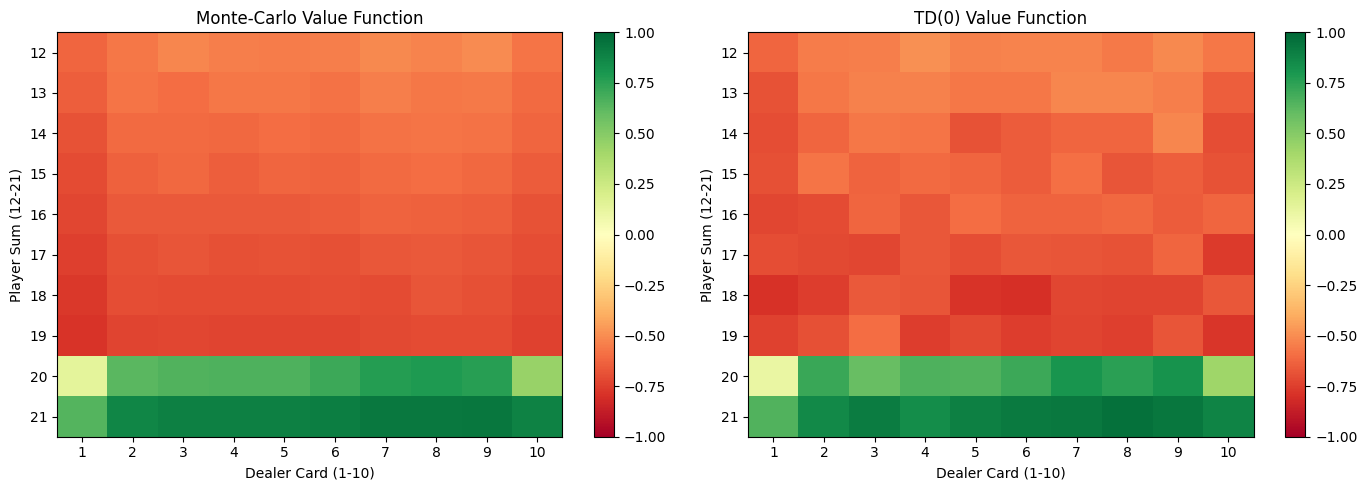

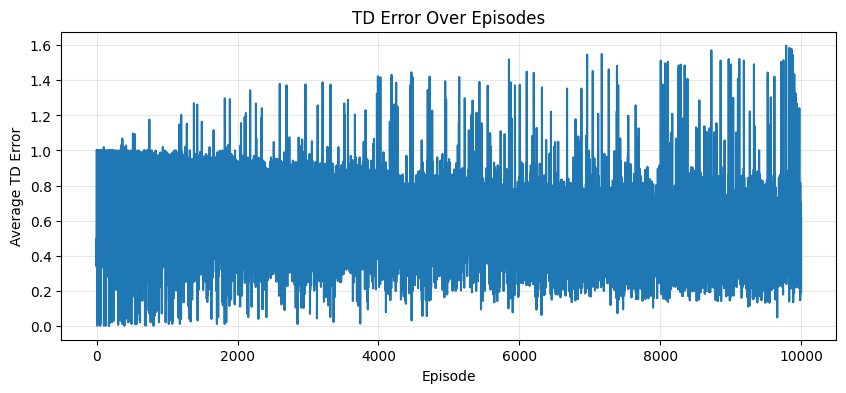

In [4]:
import matplotlib.pyplot as plt

# Create comparison dataframe
comparison_df = states_df.copy()
comparison_df['value_mc'] = comparison_df.apply(
    lambda row: V[row['player_sum'] - 12, row['dealer_card'] - 1, int(row['usable_ace'])],
    axis=1
)
comparison_df['value_td0'] = comparison_df.apply(
    lambda row: V_td0[row['player_sum'] - 12, row['dealer_card'] - 1, int(row['usable_ace'])],
    axis=1
)
comparison_df['difference'] = comparison_df['value_mc'] - comparison_df['value_td0']

print(comparison_df)

# Visualization: Compare MC vs TD values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MC values
mc_values = V[:, :, 0]  # No usable ace
im1 = axes[0].imshow(mc_values, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
axes[0].set_title('Monte-Carlo Value Function')
axes[0].set_xlabel('Dealer Card (1-10)')
axes[0].set_ylabel('Player Sum (12-21)')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(range(1, 11))
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(range(12, 22))
plt.colorbar(im1, ax=axes[0])

# TD values
td_values = V_td0[:, :, 0]  # No usable ace
im2 = axes[1].imshow(td_values, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
axes[1].set_title('TD(0) Value Function')
axes[1].set_xlabel('Dealer Card (1-10)')
axes[1].set_ylabel('Player Sum (12-21)')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(range(1, 11))
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(range(12, 22))
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

# Plot TD error convergence
plt.figure(figsize=(10, 4))
plt.plot(td_err_curve[:10000])
plt.title('TD Error Over Episodes')
plt.xlabel('Episode')
plt.ylabel('Average TD Error')
plt.grid(True, alpha=0.3)
plt.show()

### Advantages and Disadvantages of MC vs. TD

#### TD

- TD can learn before knowing the final outcome

    - TD can learn online after every step
    - MC must wait until end of episode before return is known

- TD can learn without the final outcome

    - TD can learn from incomplete sequences
    - MC can only learn from complete sequences
    - TD works in continuing (non-terminating) environments
    - MC only works for episodic (terminating) environments
- more efficient than MC
- more sensitive to initial value

#### MC 

- Good convergence 
- Not very sensitive to initial value
- simple to understand and use


### Batch MC and TD

- MC and TD converge: $V(s) \rightarrow v_\pi(s)$ as experience $\rightarrow \infty$
- But what about batch solution for finite experience?

$$s_1^1, a_1^1, r_2^1, \ldots, s_{T_1}^1$$
$$\vdots$$
$$s_1^K, a_1^K, r_2^K, \ldots, s_{T_K}^K$$

- e.g. Repeatedly sample episode $k \in [1, K]$
- Apply MC or TD(0) to episode $k$

Both MC and TD are guaranteed to converge to the true $v_\pi(s)$ given
infinite experience — that's the theory. 
But in practice you have a fixed finite dataset of K episodes.

**Batch setting**: instead of collecting new data forever, you have K recorded episodes and you repeatedly loop over them, applying MC or TD updates each pass. This is called batch learning.

Given the same finite data, do MC and TD converge to the same answer? The answer is no 

### Certainty Equivalence

<img src="./imgs/image-81.png" width="500px"/></div>


- MC converges to solution with minimum mean-squared error
  - Best fit to the observed returns
    $$\sum_{k=1}^{K} \sum_{t=1}^{T_k} \left(G_t^k - V(s_t^k)\right)^2$$
  - In the AB example, $V(A) = 0$, state A was only visited once, with return 0, so MC fits that literally

- TD(0) converges to solution of max likelihood Markov model
  - Solution to the MDP $\langle S, \mathcal{A}, \hat{P}, \hat{R}, \gamma \rangle$ that best fits the data
    
    $$\hat{P}_{s,s'}^a = \frac{1}{N(s,a)} \sum_{k=1}^{K} \sum_{t=1}^{T_k} \mathbf{1}(s_t^k, a_t^k, s_{t+1}^k = s, a, s')$$

        estimated transition probability = fraction of times action a in state s led to s'

    $$\hat{R}_s^a = \frac{1}{N(s,a)} \sum_{k=1}^{K} \sum_{t=1}^{T_k} \mathbf{1}(s_t^k, a_t^k = s, a) r_t^k$$
    
        estimated reward = average reward received when taking action a in state s

  - In the AB example, $V(A) = 0.75$, TD bootstraps through B, which had a 75% success rate, so A inherits that estimate

  TD(0) generalizes better when the Markov assumption holds; MC is more conservative and can underfit when data is sparse.
  - TD exploits markov property
  - MC does not exploit markov property -> more effective in non markov env.

nb: idea of backup is literrally that you move forward and then you come back to $S_t$

#### Monte-Carlo Backup
<img src="./imgs/image-82.png" width="500px"/></div>

#### Temporal-Diﬀerence Backup
<img src="./imgs/image-83.png" width="500px"/></div>

####  Dynamic Programming Backup
<img src="./imgs/image-84.png" width="500px"/></div>

- Bootstrapping: update involves an estimate, using your current value estimate to update another estimate ("learning from estimates")
    - MC does not bootstrap, no estimate involved
    - TD/DP bootstraps
    
- Sampling: update samples an expectation, whether you average over all possible next states or just one sampled transition
    - DP does not sample
    - MC/TD samples, because observe trajectory (what happened)
    

## $TD(\lambda)$

#### N steps returns
<img src="./imgs/image-85.png" width="500px">

- Consider the following $n$-step returns for $n = 1, 2, \infty$:

$$n=1 \quad (TD) \quad G_t^{(1)} = R_{t+1} + \gamma V(S_{t+1})$$
$$n=2 \quad\qquad\quad G_t^{(2)} = R_{t+1} + \gamma R_{t+2} + \gamma^2 V(S_{t+2})$$
$$\vdots$$
$$n=\infty \quad (MC) \quad G_t^{(\infty)} = R_{t+1} + \gamma R_{t+2} + ... + \gamma^{T-1} R_T$$

- Define the $n$-step return

$$G_t^{(n)} = R_{t+1} + \gamma R_{t+2} + ... + \gamma^{n-1} R_{t+n} + \gamma^n V(S_{t+n})$$

- $n$-step temporal-difference learning

$$V(S_t) \leftarrow V(S_t) + \alpha \left( G_t^{(n)} - V(S_t) \right)$$

#### Averaging n-steps return

<img src="./imgs/image-87.png" width="500px">

<img src="./imgs/image-86.png" width="500px">

#### TD($\lambda$) weighting function

<img src="./imgs/image-88.png" width="500px">

### 2 views

Different view of same algorithm, from different perspectives

- Forward view (theoritical)

- Backward view (practical)

#### Forward view TD($\lambda$) 


<img src="./imgs/image-89.png" width="500px">

- At each state, look ahead into the future
- Compute the λ-return $G_t^\lambda$: a weighted mix of 1-step, 2-step, ... T-step returns
- Requires knowing the future → not implementable online

#### Backward view TD($\lambda$) 
- Forward view provides theory
- Backward view provides mechanism
- At each step, look back at previously visited states
- Use eligibility traces to propagate current TD error backward. 
- fully online and implementable
- backward view: accumulate eligibility traces


The theorem guarantees they produce identical total updates over an episode — so the backward view is just an efficient, online way to compute what the forward view prescribes.

#### Eligibility Traces


<img src="../image-90.png" width="500px">

Eligibility traces answer the question: which states are "eligible" to receive a credit (or blame) for the current TD error?

**The idea**:

- When you visit a state, it becomes eligible for updates
- Its eligibility decays over time (factor $\gamma\lambda$)
- When a TD error $\delta_t$ occurs,all eligible states get updated, proportional to their current trace value
- $\lambda$ controls the memory length: how far back in time credit can propagate

Two extremes:

- $\lambda = 0$ → only the current state gets updated (pure TD(0))

- $\lambda = 1$ → all visited states accumulate credit → equivalent to Monte Carlo

**Intuitively**: imagine a rat running a maze and getting food at the end. Which rooms "caused" the reward? Eligibility traces assign credit backward through recently visited states — the more recent and frequent the visit, the higher the eligibility.

#### Backward view TD($\lambda$) 


<img src="./imgs/image-91.png" width="500px">

#### TD($\lambda$) and TD(0)

- When $\lambda = 0$, only current state is updated

    $E_t(s) = \mathbf{1}(S_t = s)$, 1 if condition is true ($S_t$ is s), 0 otherwise

    $V(s) \leftarrow V(s) + \alpha \delta_t E_t(s)$

- This is exactly equivalent to TD(0) update

$$V(S_t) \leftarrow V(S_t) + \alpha \delta_t$$

#### TD($\lambda$) and MC

- When $\lambda = 1$, credit is deferred until end of episode
- Consider episodic environments with offline updates
- Over the course of an episode, total update for TD(1) is the same as total update for MC

> **Theorem**
>
> *The sum of offline updates is identical for forward-view and backward-view TD($\lambda$)*
>
> $$\sum_{t=1}^{T} \alpha \delta_t E_t(s) = \sum_{t=1}^{T} \alpha \left( G_t^{\lambda} - V(S_t) \right) \mathbf{1}(S_t = s)$$

In conclusion -> Pick lambda to find a sweet spot between TD(0) and MC